
# Week 3 — Data Processing and Exploitation

## AI Supply Chain Threat Intelligence

**Goal:** transform the raw Week 2 threat-intelligence observations into a clean, validated, normalized, enriched, and correlated CTI dataset.

### Input files from Week 2
- `observables.csv` — raw observables and historical IOC candidates
- `cases.csv` — case-level context
- `atlas_mappings.csv` — selected MITRE ATLAS technique mappings

### Processing stages
1. Load and inspect the raw data
2. Clean whitespace and remove exact duplicates
3. Normalize values by indicator type
4. Validate indicator syntax
5. Filter IOC candidates from contextual records
6. Enrich indicators with case metadata
7. Correlate indicators with MITRE ATLAS techniques
8. Export CSV/JSON results and charts

> **Evidence boundary:** this notebook performs offline data processing only. It does not connect to, scan, query, or reputation-check any reported IP address, domain, repository, or file hash. Historical indicators remain historical unless separately verified.


## 1. Upload the Week 2 source files

In [ ]:

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import ipaddress
import re
import json
import shutil
from pathlib import Path

print("Upload these three files from week2/data/:")
print("  1) observables.csv")
print("  2) cases.csv")
print("  3) atlas_mappings.csv")
uploaded = files.upload()

required = {"observables.csv", "cases.csv", "atlas_mappings.csv"}
missing = required - set(uploaded.keys())

if missing:
    raise FileNotFoundError(
        "Missing required file(s): " + ", ".join(sorted(missing)) +
        ". Re-run this cell and upload all three files."
    )

print("\nAll required files were uploaded successfully.")


Upload these three files from week2/data/:
  1) observables.csv
  2) cases.csv
  3) atlas_mappings.csv


## 2. Load and inspect the raw datasets

In [ ]:

observables = pd.read_csv("observables.csv", dtype=str, keep_default_na=False)
cases = pd.read_csv("cases.csv", dtype=str, keep_default_na=False)
mappings = pd.read_csv("atlas_mappings.csv", dtype=str, keep_default_na=False)

print("Observables:", observables.shape)
print("Cases:", cases.shape)
print("ATLAS mappings:", mappings.shape)

display(observables.head())



### Interpretation

`observables.csv` is the primary raw dataset. It contains both historical IOC candidates and contextual records.  
The other two files are used later for enrichment and correlation; they do not create new indicators.


## 3. Basic cleaning and exact deduplication

In [5]:

raw_count = len(observables)

# Remove leading/trailing whitespace from every text field.
clean = observables.copy()
for column in clean.columns:
    clean[column] = clean[column].astype(str).str.strip()

# Remove exact duplicates based on the identity of an observable in a case.
duplicate_key = ["case_id", "type", "value_as_reported"]
duplicate_mask = clean.duplicated(subset=duplicate_key, keep="first")
duplicate_count = int(duplicate_mask.sum())

clean = clean.loc[~duplicate_mask].copy()
after_dedup_count = len(clean)

print(f"Raw records: {raw_count}")
print(f"Exact duplicates removed: {duplicate_count}")
print(f"Records after deduplication: {after_dedup_count}")


Raw records: 12
Exact duplicates removed: 0
Records after deduplication: 12


## 4. Normalize values

In [6]:

DOMAIN_RE = re.compile(
    r"^(?=.{1,253}$)(?:[a-z0-9](?:[a-z0-9-]{0,61}[a-z0-9])?\.)+[a-z0-9](?:[a-z0-9-]{0,61}[a-z0-9])?$",
    re.IGNORECASE
)

PACKAGE_RE = re.compile(r"^[A-Za-z0-9](?:[A-Za-z0-9._-]*[A-Za-z0-9])?$")

def refang_dots(value):
    value = str(value).strip()
    return (
        value.replace("[.]", ".")
             .replace("(.)", ".")
             .replace("{.}", ".")
    )

def normalize_value(row):
    value = str(row["value_as_reported"]).strip()
    observable_type = str(row["type"]).strip().lower()

    if observable_type in {"sha1", "sha256"}:
        return value.lower()

    if observable_type == "ipv4":
        return refang_dots(value)

    if observable_type == "domain":
        return refang_dots(value).lower().rstrip(".")

    if observable_type == "domain_pattern":
        # Preserve the wildcard but normalize the domain portion.
        value = refang_dots(value).lower().rstrip(".")
        return value

    # Repository identifiers, package names, and file paths are contextual.
    # Preserve their content and only strip surrounding whitespace.
    return value

clean["normalized_value"] = clean.apply(normalize_value, axis=1)

def normalization_note(row):
    original = str(row["value_as_reported"])
    normalized = str(row["normalized_value"])

    if original == normalized:
        return "no change required"

    changes = []
    if "[.]" in original or "(.)" in original or "{.}" in original:
        changes.append("refanged dot notation")
    if original.lower() == normalized and original != normalized:
        changes.append("lowercased")
    if not changes:
        changes.append("canonical formatting applied")

    return "; ".join(changes)

clean["normalization_notes"] = clean.apply(normalization_note, axis=1)
clean["was_normalized"] = clean["value_as_reported"] != clean["normalized_value"]

display(
    clean[
        ["observable_id", "type", "value_as_reported",
         "normalized_value", "was_normalized", "normalization_notes"]
    ]
)


,observable_id,type,value_as_reported,normalized_value,was_normalized,normalization_notes
0,OBS001,sha1,1733506c584dd6801accf7f58dc92a4a1285db1f,1733506c584dd6801accf7f58dc92a4a1285db1f,False,no change required
1,OBS002,sha1,79601f536b1b351c695507bf37236139f42201b0,79601f536b1b351c695507bf37236139f42201b0,False,no change required
2,OBS003,sha1,0dcc38fc90eca38810805bb03b9f6bb44945bbc0,0dcc38fc90eca38810805bb03b9f6bb44945bbc0,False,no change required
3,OBS004,sha1,85c898c5db096635a21a9e8b5be0a58648205b47,85c898c5db096635a21a9e8b5be0a58648205b47,False,no change required
4,OBS005,repository_identifier,glockr1/ballr7,glockr1/ballr7,False,no change required
5,OBS006,repository_identifier,who-r-u0000/0000000000000000000000000000000000000,who-r-u0000/0000000000000000000000000000000000000,False,no change required
6,OBS007,ipv4,107.173.7.141,107.173.7.141,False,no change required
7,OBS008,sha256,2385b29489cd9e35f92c072780f903ae2e517ed422eae6...,2385b29489cd9e35f92c072780f903ae2e517ed422eae6...,False,no change required
8,OBS009,domain_pattern,*.h4ck[.]cfd,*.h4ck.cfd,True,refanged dot notation
9,OBS010,domain,wheezy[.]io,wheezy.io,True,refanged dot notation


## 5. Validate indicator syntax

In [7]:

def is_valid_sha1(value):
    return bool(re.fullmatch(r"[0-9a-fA-F]{40}", value))

def is_valid_sha256(value):
    return bool(re.fullmatch(r"[0-9a-fA-F]{64}", value))

def is_valid_ipv4(value):
    try:
        return isinstance(ipaddress.ip_address(value), ipaddress.IPv4Address)
    except ValueError:
        return False

def is_valid_domain(value):
    return bool(DOMAIN_RE.fullmatch(value))

def is_valid_domain_pattern(value):
    if value.startswith("*."):
        return is_valid_domain(value[2:])
    return is_valid_domain(value)

def validate_row(row):
    observable_type = row["type"].lower()
    value = row["normalized_value"]

    if observable_type == "sha1":
        return is_valid_sha1(value)
    if observable_type == "sha256":
        return is_valid_sha256(value)
    if observable_type == "ipv4":
        return is_valid_ipv4(value)
    if observable_type == "domain":
        return is_valid_domain(value)
    if observable_type == "domain_pattern":
        return is_valid_domain_pattern(value)

    # Contextual types are not network/hash IOC syntax.
    # They are retained as context and marked not applicable here.
    return None

clean["syntax_valid"] = clean.apply(validate_row, axis=1)

def indicator_family(observable_type):
    if observable_type in {"sha1", "sha256"}:
        return "file_hash"
    if observable_type in {"ipv4", "domain", "domain_pattern"}:
        return "network"
    return "context"

clean["indicator_family"] = clean["type"].str.lower().map(indicator_family)
clean["record_class"] = clean["assessment_scope"].apply(
    lambda x: "ioc_candidate" if x == "historical_ioc_candidate" else "context"
)

display(
    clean[
        ["observable_id", "type", "normalized_value",
         "record_class", "indicator_family", "syntax_valid"]
    ]
)


,observable_id,type,normalized_value,record_class,indicator_family,syntax_valid
0,OBS001,sha1,1733506c584dd6801accf7f58dc92a4a1285db1f,ioc_candidate,file_hash,True
1,OBS002,sha1,79601f536b1b351c695507bf37236139f42201b0,ioc_candidate,file_hash,True
2,OBS003,sha1,0dcc38fc90eca38810805bb03b9f6bb44945bbc0,ioc_candidate,file_hash,True
3,OBS004,sha1,85c898c5db096635a21a9e8b5be0a58648205b47,ioc_candidate,file_hash,True
4,OBS005,repository_identifier,glockr1/ballr7,context,context,None
5,OBS006,repository_identifier,who-r-u0000/0000000000000000000000000000000000000,context,context,None
6,OBS007,ipv4,107.173.7.141,ioc_candidate,network,True
7,OBS008,sha256,2385b29489cd9e35f92c072780f903ae2e517ed422eae6...,ioc_candidate,file_hash,True
8,OBS009,domain_pattern,*.h4ck.cfd,ioc_candidate,network,True
9,OBS010,domain,wheezy.io,ioc_candidate,network,True



### Validation rule

Only hash and network IOC types are syntax-validated. Repository identifiers, package names, and file paths are retained as context rather than incorrectly treated as malicious indicators by themselves.


## 6. Filter valid IOC candidates

In [8]:

supported_ioc_types = {"sha1", "sha256", "ipv4", "domain", "domain_pattern"}

ioc_candidate_mask = (
    clean["assessment_scope"].eq("historical_ioc_candidate")
    & clean["type"].str.lower().isin(supported_ioc_types)
)

ioc_candidates_before_validation = clean.loc[ioc_candidate_mask].copy()

valid_iocs = clean.loc[
    ioc_candidate_mask & clean["syntax_valid"].eq(True)
].copy()

invalid_iocs = clean.loc[
    ioc_candidate_mask & ~clean["syntax_valid"].eq(True)
].copy()

context_records = clean.loc[~ioc_candidate_mask].copy()

print("IOC candidates before validation:", len(ioc_candidates_before_validation))
print("Valid IOC candidates:", len(valid_iocs))
print("Invalid IOC candidates:", len(invalid_iocs))
print("Context-only records:", len(context_records))

display(valid_iocs[
    ["observable_id", "case_id", "type", "normalized_value",
     "role", "source_id", "current_status"]
])


IOC candidates before validation: 8
Valid IOC candidates: 8
Invalid IOC candidates: 0
Context-only records: 4


,observable_id,case_id,type,normalized_value,role,source_id,current_status
0,OBS001,C01,sha1,1733506c584dd6801accf7f58dc92a4a1285db1f,model archive hash,S02,not assessed
1,OBS002,C01,sha1,79601f536b1b351c695507bf37236139f42201b0,embedded file hash,S02,not assessed
2,OBS003,C01,sha1,0dcc38fc90eca38810805bb03b9f6bb44945bbc0,model archive hash,S02,not assessed
3,OBS004,C01,sha1,85c898c5db096635a21a9e8b5be0a58648205b47,embedded file hash,S02,not assessed
6,OBS007,C01,ipv4,107.173.7.141,reported callback address,S02,not assessed
7,OBS008,C02,sha256,2385b29489cd9e35f92c072780f903ae2e517ed422eae6...,malicious binary hash,S03,not assessed
8,OBS009,C02,domain_pattern,*.h4ck.cfd,reported exfiltration destination pattern,S03,not assessed
9,OBS010,C02,domain,wheezy.io,reported DNS server domain,S03,not assessed


## 7. Enrich with case-level context

In [9]:

case_columns = [
    "case_id",
    "atlas_id",
    "title",
    "atlas_type",
    "component",
    "distribution_channel",
    "mechanism",
    "reported_effect",
    "evidence_boundary"
]

case_context = cases[case_columns].copy()

enriched = valid_iocs.merge(
    case_context,
    on="case_id",
    how="left",
    validate="many_to_one"
)

print("Valid indicators after case enrichment:", len(enriched))
display(enriched[
    ["observable_id", "type", "normalized_value",
     "atlas_id", "title", "component", "distribution_channel"]
])


Valid indicators after case enrichment: 8


,observable_id,type,normalized_value,atlas_id,title,component,distribution_channel
0,OBS001,sha1,1733506c584dd6801accf7f58dc92a4a1285db1f,AML.CS0031,Malicious Models on Hugging Face,Serialized model artifact,Hugging Face
1,OBS002,sha1,79601f536b1b351c695507bf37236139f42201b0,AML.CS0031,Malicious Models on Hugging Face,Serialized model artifact,Hugging Face
2,OBS003,sha1,0dcc38fc90eca38810805bb03b9f6bb44945bbc0,AML.CS0031,Malicious Models on Hugging Face,Serialized model artifact,Hugging Face
3,OBS004,sha1,85c898c5db096635a21a9e8b5be0a58648205b47,AML.CS0031,Malicious Models on Hugging Face,Serialized model artifact,Hugging Face
4,OBS007,ipv4,107.173.7.141,AML.CS0031,Malicious Models on Hugging Face,Serialized model artifact,Hugging Face
5,OBS008,sha256,2385b29489cd9e35f92c072780f903ae2e517ed422eae6...,AML.CS0015,Compromised PyTorch Dependency Chain,AI software dependency,PyPI / PyTorch nightly dependency resolution
6,OBS009,domain_pattern,*.h4ck.cfd,AML.CS0015,Compromised PyTorch Dependency Chain,AI software dependency,PyPI / PyTorch nightly dependency resolution
7,OBS010,domain,wheezy.io,AML.CS0015,Compromised PyTorch Dependency Chain,AI software dependency,PyPI / PyTorch nightly dependency resolution


## 8. Correlate with MITRE ATLAS techniques

In [10]:

def join_unique(series):
    values = [str(v).strip() for v in series if str(v).strip()]
    return "; ".join(sorted(set(values)))

mapping_summary = (
    mappings.groupby("case_id", as_index=False)
    .agg({
        "technique_id": join_unique,
        "technique_display_name": join_unique,
        "tactic_name": join_unique
    })
    .rename(columns={
        "technique_id": "related_atlas_technique_ids",
        "technique_display_name": "related_atlas_techniques",
        "tactic_name": "related_atlas_tactics"
    })
)

enriched = enriched.merge(
    mapping_summary,
    on="case_id",
    how="left",
    validate="many_to_one"
)

enriched["related_atlas_technique_count"] = enriched[
    "related_atlas_technique_ids"
].fillna("").apply(
    lambda x: 0 if not x else len([v for v in x.split("; ") if v])
)

display(enriched[
    ["observable_id", "normalized_value", "title",
     "related_atlas_technique_ids", "related_atlas_tactics"]
])


,observable_id,normalized_value,title,related_atlas_technique_ids,related_atlas_tactics
0,OBS001,1733506c584dd6801accf7f58dc92a4a1285db1f,Malicious Models on Hugging Face,AML.T0010; AML.T0011.000; AML.T0018.002; AML.T...,AI Attack Adaptation; Execution; Initial Acces...
1,OBS002,79601f536b1b351c695507bf37236139f42201b0,Malicious Models on Hugging Face,AML.T0010; AML.T0011.000; AML.T0018.002; AML.T...,AI Attack Adaptation; Execution; Initial Acces...
2,OBS003,0dcc38fc90eca38810805bb03b9f6bb44945bbc0,Malicious Models on Hugging Face,AML.T0010; AML.T0011.000; AML.T0018.002; AML.T...,AI Attack Adaptation; Execution; Initial Acces...
3,OBS004,85c898c5db096635a21a9e8b5be0a58648205b47,Malicious Models on Hugging Face,AML.T0010; AML.T0011.000; AML.T0018.002; AML.T...,AI Attack Adaptation; Execution; Initial Acces...
4,OBS007,107.173.7.141,Malicious Models on Hugging Face,AML.T0010; AML.T0011.000; AML.T0018.002; AML.T...,AI Attack Adaptation; Execution; Initial Acces...
5,OBS008,2385b29489cd9e35f92c072780f903ae2e517ed422eae6...,Compromised PyTorch Dependency Chain,AML.T0010.001,Initial Access
6,OBS009,*.h4ck.cfd,Compromised PyTorch Dependency Chain,AML.T0010.001,Initial Access
7,OBS010,wheezy.io,Compromised PyTorch Dependency Chain,AML.T0010.001,Initial Access



### Correlation interpretation

The correlation is **case-based**, not a claim that one hash or domain uniquely proves every related technique.  
An observable inherits the selected ATLAS context of the case in which the source reported it.


## 9. Processing summary

In [11]:

summary = pd.DataFrame([
    {"stage": "Raw Week 2 records", "count": raw_count},
    {"stage": "After exact deduplication", "count": after_dedup_count},
    {"stage": "Historical IOC candidates", "count": len(ioc_candidates_before_validation)},
    {"stage": "Valid IOC candidates", "count": len(valid_iocs)},
    {"stage": "Context-only records", "count": len(context_records)},
    {"stage": "Invalid IOC candidates", "count": len(invalid_iocs)},
])

display(summary)


,stage,count
0,Raw Week 2 records,12
1,After exact deduplication,12
2,Historical IOC candidates,8
3,Valid IOC candidates,8
4,Context-only records,4
5,Invalid IOC candidates,0


## 10. Visualize the processed dataset

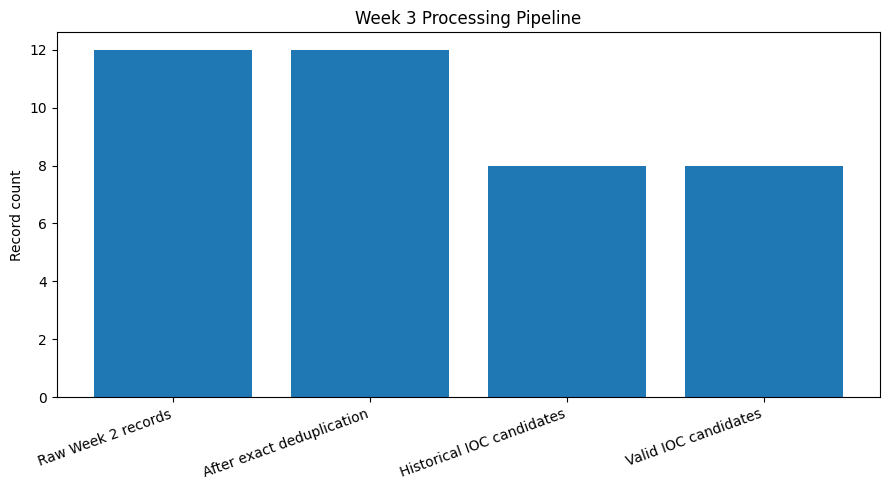

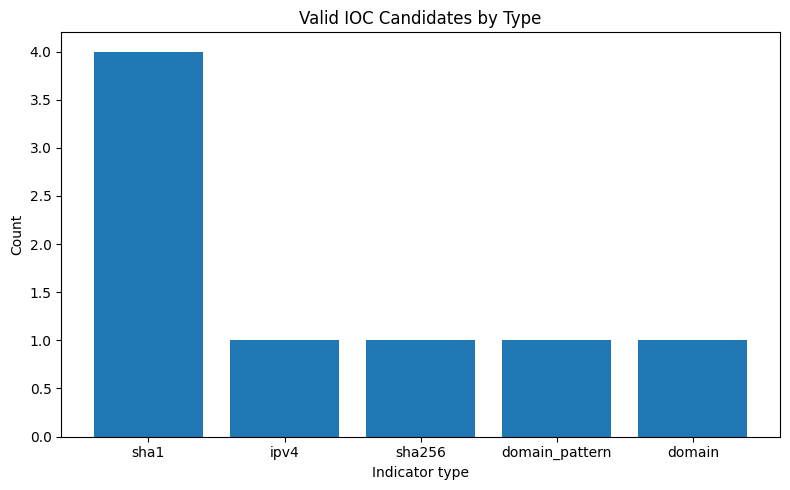

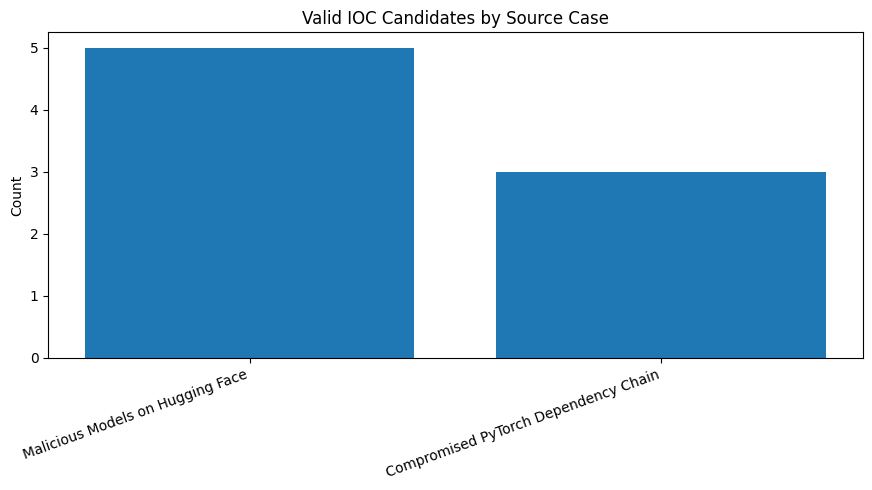

In [12]:

OUTPUT_ROOT = Path("week3_output")
DATA_DIR = OUTPUT_ROOT / "data"
IMAGE_DIR = OUTPUT_ROOT / "images"
EVIDENCE_DIR = OUTPUT_ROOT / "evidence"

for directory in [DATA_DIR, IMAGE_DIR, EVIDENCE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Chart 1: processing stages
plot_summary = summary[summary["stage"].isin([
    "Raw Week 2 records",
    "After exact deduplication",
    "Historical IOC candidates",
    "Valid IOC candidates"
])]

plt.figure(figsize=(9, 5))
plt.bar(plot_summary["stage"], plot_summary["count"])
plt.title("Week 3 Processing Pipeline")
plt.ylabel("Record count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "before_after_processing.png", dpi=180, bbox_inches="tight")
plt.show()

# Chart 2: valid indicator types
type_counts = (
    valid_iocs["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))
plt.bar(type_counts["type"], type_counts["count"])
plt.title("Valid IOC Candidates by Type")
plt.xlabel("Indicator type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "indicator_types.png", dpi=180, bbox_inches="tight")
plt.show()

# Chart 3: valid indicators by case
case_counts = (
    enriched["title"]
    .value_counts()
    .rename_axis("case")
    .reset_index(name="count")
)

plt.figure(figsize=(9, 5))
plt.bar(case_counts["case"], case_counts["count"])
plt.title("Valid IOC Candidates by Source Case")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "indicators_by_case.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Export processed CTI datasets

In [13]:

# 1) Full cleaned Week 2 observables
clean.to_csv(DATA_DIR / "cleaned_observables.csv", index=False)

# 2) Final normalized IOC candidates
normalized_columns = [
    "observable_id",
    "case_id",
    "type",
    "value_as_reported",
    "normalized_value",
    "role",
    "source_id",
    "source_url",
    "source_publication_date",
    "current_status",
    "to_ids",
    "normalization_notes",
    "indicator_family"
]

normalized_iocs = valid_iocs[normalized_columns].copy()
normalized_iocs.to_csv(DATA_DIR / "normalized_iocs.csv", index=False)

# 3) Enriched and correlated result
enriched.to_csv(DATA_DIR / "enriched_indicators.csv", index=False)

# 4) Machine-readable JSON
json_records = enriched.where(pd.notnull(enriched), None).to_dict(orient="records")
with open(DATA_DIR / "indicators.json", "w", encoding="utf-8") as f:
    json.dump(json_records, f, indent=2, ensure_ascii=False)

# 5) Processing summary
summary.to_csv(DATA_DIR / "processing_summary.csv", index=False)

print("Exported files:")
for path in sorted(DATA_DIR.iterdir()):
    print(" -", path)


Exported files:
 - week3_output/data/cleaned_observables.csv
 - week3_output/data/enriched_indicators.csv
 - week3_output/data/indicators.json
 - week3_output/data/normalized_iocs.csv
 - week3_output/data/processing_summary.csv


## 12. Create a reproducible evidence summary

In [14]:

normalized_changes = int(clean["was_normalized"].sum())

evidence_text = f"""Week 3 — Data Processing Evidence
=================================
Raw Week 2 records: {raw_count}
Exact duplicates removed: {duplicate_count}
Records after deduplication: {after_dedup_count}
Records whose value changed during normalization: {normalized_changes}
Historical IOC candidates before validation: {len(ioc_candidates_before_validation)}
Valid IOC candidates: {len(valid_iocs)}
Invalid IOC candidates: {len(invalid_iocs)}
Context-only records: {len(context_records)}

Processing performed:
- whitespace cleaning
- exact deduplication
- type-aware normalization
- syntax validation
- IOC/context filtering
- case-level enrichment
- case-to-MITRE-ATLAS correlation

Important boundary:
No live IP/domain/hash/repository reputation lookup or scanning was performed.
The output preserves the historical/current-status limitations recorded in Week 2.
"""

evidence_path = EVIDENCE_DIR / "processing_summary.txt"
evidence_path.write_text(evidence_text, encoding="utf-8")

print(evidence_text)


Week 3 — Data Processing Evidence
Raw Week 2 records: 12
Exact duplicates removed: 0
Records after deduplication: 12
Records whose value changed during normalization: 2
Historical IOC candidates before validation: 8
Valid IOC candidates: 8
Invalid IOC candidates: 0
Context-only records: 4

Processing performed:
- whitespace cleaning
- exact deduplication
- type-aware normalization
- syntax validation
- IOC/context filtering
- case-level enrichment
- case-to-MITRE-ATLAS correlation

Important boundary:
No live IP/domain/hash/repository reputation lookup or scanning was performed.
The output preserves the historical/current-status limitations recorded in Week 2.



## 13. Quality checks

In [15]:

checks = {
    "No duplicate final IOC rows":
        not normalized_iocs.duplicated(
            subset=["case_id", "type", "normalized_value"]
        ).any(),

    "All final IOC candidates passed syntax validation":
        bool(valid_iocs["syntax_valid"].eq(True).all()),

    "Every final IOC has a source URL":
        bool(valid_iocs["source_url"].str.strip().ne("").all()),

    "Every final IOC has case enrichment":
        bool(enriched["title"].str.strip().ne("").all()),

    "Every final IOC has at least one correlated ATLAS technique":
        bool(enriched["related_atlas_technique_count"].gt(0).all()),
}

checks_df = pd.DataFrame(
    [{"check": name, "passed": passed} for name, passed in checks.items()]
)

display(checks_df)

if not checks_df["passed"].all():
    raise AssertionError("One or more quality checks failed.")

print("All quality checks passed.")


,check,passed
0,No duplicate final IOC rows,True
1,All final IOC candidates passed syntax validation,True
2,Every final IOC has a source URL,True
3,Every final IOC has case enrichment,True
4,Every final IOC has at least one correlated AT...,True


All quality checks passed.


## 14. Package and download the Week 3 results

In [16]:

archive_base = "week3_colab_results"
archive_path = shutil.make_archive(archive_base, "zip", root_dir=OUTPUT_ROOT)

print("Created:", archive_path)
print("\nThe ZIP contains:")
for path in sorted(OUTPUT_ROOT.rglob("*")):
    if path.is_file():
        print(" -", path)

files.download(archive_path)


Created: /content/week3_colab_results.zip

The ZIP contains:
 - week3_output/data/cleaned_observables.csv
 - week3_output/data/enriched_indicators.csv
 - week3_output/data/indicators.json
 - week3_output/data/normalized_iocs.csv
 - week3_output/data/processing_summary.csv
 - week3_output/evidence/processing_summary.txt
 - week3_output/images/before_after_processing.png
 - week3_output/images/indicator_types.png
 - week3_output/images/indicators_by_case.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>